In [10]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import diffrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from rich import print

from pymcsimmod import model
from pymcsimmod.parser import ModelParser

from pymcsimmod import JaxModel, ScipyModel

import pymc as pm
import pytensor.tensor as pt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
filename = Path("../../tests/data/exponential.model")
assert filename.exists()
parser = ModelParser()
parsed_model = parser.parse(filename.read_text())

# Solve jax model

<Axes: xlabel='Time', ylabel='Value'>

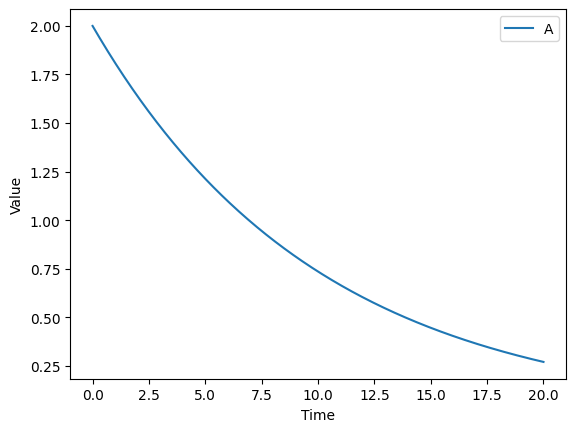

In [9]:
jax_model = JaxModel(model=filename)
jax_model.update_Y0(A=2)
jax_model.update_constants(r=-0.1)
times = np.linspace(0, 20, 500)
solution = jax_model.run_model(times)
solution.plot_results(variables=["A"])

In [ ]:
n_time_points = 20

class SolOp(Op):
    """Simple, working ODE Op - optimized for reliability over generality."""
    __props__ = ("_solve_function",)
    
    def __init__(self, solve_function):
        self._solve_function = solve_function
        self._jit_solve = jax.jit(solve_function)
        # VJP for exactly the parameters this function expects
        self._vjp_fun = jax.jit(lambda y0, p: jax.vjp(solve_function, y0, p))
    
    def make_node(self, y0, p):
        inputs = [pt.as_tensor_variable(y0), pt.as_tensor_variable(p)]
        outputs = [pt.vector(dtype="float64", shape=(n_time_points,))]
        return Apply(self, inputs, outputs)

    def perform(self, node, inputs, outputs):
        y0, p = inputs
        result = self._jit_solve(y0, p)
        outputs[0][0] = np.asarray(result, dtype="float64")

    def grad(self, inputs, output_grads):
        """Use JAX VJP for efficient gradient computation."""
        y0, p = inputs
        output_grad = output_grads[0]
        
        vjp_op = VJPOp(self._vjp_fun)
        grad_y0, grad_p = vjp_op(y0, p, output_grad)
        return [grad_y0, grad_p]


class VJPOp(Op):
    """VJP computation for 2-parameter case."""
    __props__ = ("_vjp_fun",)
    
    def __init__(self, vjp_fun):
        self._vjp_fun = vjp_fun
    
    def make_node(self, y0, p, output_grad):
        inputs = [pt.as_tensor_variable(y0), pt.as_tensor_variable(p), 
                 pt.as_tensor_variable(output_grad)]
        outputs = [pt.scalar(dtype="float64"), pt.scalar(dtype="float64")]
        return Apply(self, inputs, outputs)

    def perform(self, node, inputs, outputs):
        y0, p, output_grad = inputs
        result, vjp_fn = self._vjp_fun(y0, p)
        grad_y0, grad_p = vjp_fn(output_grad)
        outputs[0][0] = np.asarray(grad_y0, dtype="float64")
        outputs[1][0] = np.asarray(grad_p, dtype="float64")